## Test test

In [1]:
# setup imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path().resolve().parents[2]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pickle
import warnings
from pathlib import Path

import seaborn as sns

from src.models import *
from src.paths import *

warnings.filterwarnings("ignore", category=UserWarning)

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [3]:
results_folder = Path("result_analysis")
result_files = list(results_folder.glob("result_seed_*.pkl"))

loaded_results = []
for f in result_files:
    with open(f, "rb") as file:
        res = pickle.load(file)
        loaded_results.append(res)

# Example: print best objective per seed
for r in loaded_results:
    print(f"Seed {r['seed']}: best_f = {r['best_f']}, nfev = {r['nfev']}")

Seed 101010: best_f = 0.18279455472171757, nfev = 336
Seed 111222: best_f = 0.18718832984919648, nfev = 336
Seed 112233: best_f = 0.15997136878495388, nfev = 336
Seed 123456: best_f = 0.16986127012076083, nfev = 336
Seed 180988: best_f = 0.1674574328395881, nfev = 336
Seed 202020: best_f = 0.16830063801509149, nfev = 336
Seed 214025: best_f = 0.16800171601266967, nfev = 336
Seed 303030: best_f = 0.1751435585392561, nfev = 336
Seed 333444: best_f = 0.1692558476102813, nfev = 336
Seed 404040: best_f = 0.17157839814922252, nfev = 336
Seed 445566: best_f = 0.17432402847365358, nfev = 336
Seed 505050: best_f = 0.16666939353393673, nfev = 336
Seed 555666: best_f = 0.1648551976502665, nfev = 336
Seed 654321: best_f = 0.18287027035958753, nfev = 336
Seed 777888: best_f = 0.18131681226493856, nfev = 336
Seed 778899: best_f = 0.16568228131796092, nfev = 336
Seed 987654: best_f = 0.15963112321140138, nfev = 336
Seed 999000: best_f = 0.17151514486460445, nfev = 336


In [4]:
best_params_list = []

for run_idx, run in enumerate(loaded_results):
    seed = run["seed"]
    history = run["history"]

    # find the best evaluation by objective value
    best_idx = np.argmin(history["objective"])

    best_theta_phys = history["theta_phys"][best_idx]
    best_obj = history["objective"][best_idx]
    best_nse = history["nse"][best_idx]
    best_kge = history["kge"][best_idx]
    best_vol_err = history["vol_err"][best_idx]

    row = {
        "seed": seed,
        "best_eval": best_idx + 1,
        "objective": best_obj,
        "nse": best_nse,
        "kge": best_kge,
        "vol_err": best_vol_err,
    }

    # add each parameter with its proper name
    for i, th in enumerate(best_theta_phys):
        row[parameter_names[i]] = th

    best_params_list.append(row)

# create DataFrame
best_params_df = pd.DataFrame(best_params_list)
best_params_df

best_params_df.to_pickle("best_params_df_kerki.pkl")

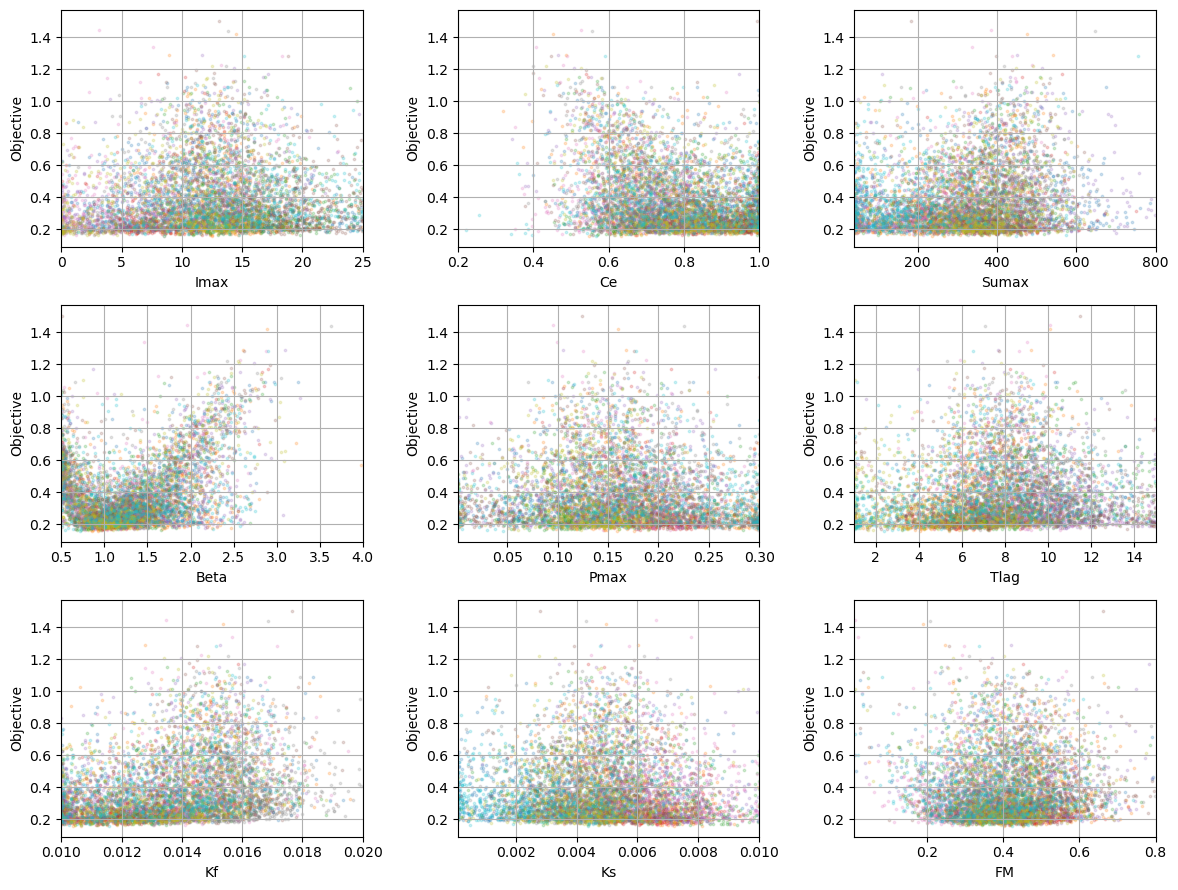

In [5]:
import numpy as np
import pandas as pd

# Suppose you have multiple seeds in `results`:
dfs = []
for seed_idx, res_seed in enumerate(loaded_results):
    hist = res_seed["history"]
    df = pd.DataFrame(hist)
    df["seed"] = seed_idx  # add a seed column
    dfs.append(df)

history_df = pd.concat(dfs, ignore_index=True)

n_params = len(p_min)  # 9
seeds = history_df["seed"].unique()  # get all unique seeds
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))  # assign colors

n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()  # flatten for easy indexing

for i in range(n_params):
    ax = axes[i]

    for seed, color in zip(seeds, colors):
        theta_array = np.stack(history_df.loc[history_df["seed"] == seed, "theta_phys"].values)
        obj_array = history_df.loc[history_df["seed"] == seed, "objective"].values
        ax.scatter(theta_array[:, i], obj_array, label=f"Seed {seed}", color=color, alpha=0.2, s=3)
        ax.set_xlabel(parameter_names[i])

    ax.set_ylabel("Objective")
    # ax.set_title()
    ax.set_xlim(p_min[i], p_max[i])
    ax.grid(True)

# remove empty axes
for j in range(n_params, len(axes)):
    fig.delaxes(axes[j])


# axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

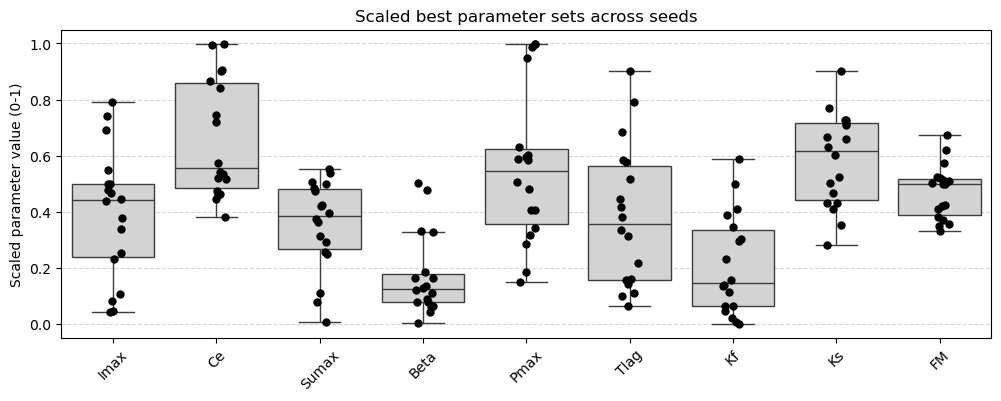

In [6]:
# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale the best parameters
scaled_params_df = pd.DataFrame(scale(best_params_df[param_cols].to_numpy()), columns=param_cols)


plt.figure(figsize=(12, 4))
# sns.boxplot(data=scaled_params_df, color = 'lightgray')
# sns.stripplot(data=scaled_params_df, color='black', jitter=False, size=8)
sns.boxplot(
    data=scaled_params_df, color="lightgray", fliersize=0
)  # light gray boxes, hide default outliers
sns.stripplot(data=scaled_params_df, color="black", jitter=True, size=6, marker="o")  # black dots

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title("Scaled best parameter sets across seeds")
# add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [7]:
rows = []

for run_idx, run in enumerate(loaded_results):
    seed = run["seed"]
    history = run["history"]

    n_eval = len(history["objective"])

    for i in range(n_eval):
        row = {
            "seed": seed,
            "eval": i + 1,
            "objective": history["objective"][i],
            "nse": history["nse"][i],
            "kge": history["kge"][i],
            "vol_err": history["vol_err"][i],
        }

        # parameters
        for j, th in enumerate(history["theta_phys"][i]):
            row[parameter_names[j]] = th

        rows.append(row)

all_results_df = pd.DataFrame(rows)
best_row = all_results_df.loc[all_results_df["objective"].idxmin()]

print(best_row)

seed         987654.000000
eval            328.000000
objective         0.159631
nse               0.644377
kge               0.825251
vol_err           0.001299
Imax              8.507048
Ce                0.566942
Sumax           448.172323
Beta              0.714943
Pmax              0.045901
Tlag              2.377915
Kf                0.011572
Ks                0.004388
FM                0.422621
Name: 5703, dtype: float64


In [8]:
q = 0.01  # best 5%
threshold = all_results_df["objective"].quantile(q)

best_5pct_df = all_results_df[all_results_df["objective"] <= threshold].sort_values("objective")

In [9]:
len(best_5pct_df), len(all_results_df)

(62, 6048)

In [10]:
best_5pct_df["seed"].value_counts()

seed
202020    12
112233    11
778899     9
214025     8
987654     5
505050     4
404040     4
180988     2
445566     2
555666     1
333444     1
123456     1
999000     1
303030     1
Name: count, dtype: int64

In [11]:
# 1. Make a copy of describe
desc_fixed = best_params_df[parameter_names].describe()

# 2. Convert count to int
desc_fixed.loc["count"] = desc_fixed.loc["count"].apply(int)

# 3. Round other stats
desc_fixed.loc[desc_fixed.index != "count"] = desc_fixed.loc[desc_fixed.index != "count"].round(3)

# 4. Set index name
desc_fixed.index.name = "Statistic"

# 5. Rename the problematic row labels (the index)
desc_fixed = desc_fixed.rename(index={"25%": "Q25", "50%": "Median", "75%": "Q75"})

# 6. Export to LaTeX
latex_table = desc_fixed.to_latex(
    index=True,
    float_format="%.3f",
    caption="Summary statistics of calibrated parameters",
    label="tab:param_summary",
    escape=False,  # safe since we removed problematic % signs
)

# 7. Write to file
with open("parameter_summary.tex", "w") as f:
    f.write(latex_table)

print("LaTeX table saved as 'parameter_summary.tex'")

LaTeX table saved as 'parameter_summary.tex'


In [12]:
print(desc_fixed.index)

Index(['count', 'mean', 'std', 'min', 'Q25', 'Median', 'Q75', 'max'], dtype='object', name='Statistic')


In [13]:
best_5pct_df[parameter_names].describe()

,Imax,Ce,Sumax,Beta,Pmax,Tlag,Kf,Ks,FM
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,9.962704,0.721782,323.719742,1.004519,0.151349,5.766939,0.011737,0.006131,0.393302
std,5.610681,0.153211,114.124363,0.322571,0.072566,2.636754,0.001205,0.001976,0.074770
min,0.017312,0.342355,46.269386,0.536770,0.005301,1.037665,0.010016,0.000510,0.200885
25%,5.912367,0.614658,237.025445,0.805981,0.104205,3.798524,0.010925,0.004716,0.338960
50%,10.571867,0.685600,341.332211,0.950243,0.146952,5.572967,0.011503,0.006542,0.404279
75%,13.342476,0.831379,401.633712,1.097156,0.196153,7.412092,0.012354,0.007343,0.451449
max,23.503204,0.999777,574.880981,2.259491,0.299909,13.646617,0.015206,0.009265,0.541143


In [14]:
# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Extract parameters as array
theta = best_5pct_df[param_cols].to_numpy()

# Apply your scaling
scaled_theta = scale(theta)

# Back to DataFrame
scaled_params_df = pd.DataFrame(scaled_theta, columns=param_cols)

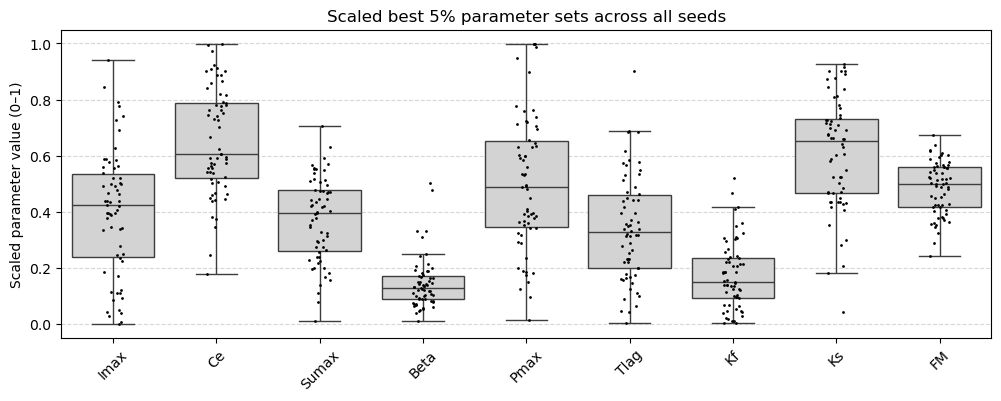

In [15]:
plt.figure(figsize=(12, 4))

sns.boxplot(data=scaled_params_df, color="lightgray", fliersize=0)

sns.stripplot(data=scaled_params_df, color="black", jitter=True, size=2, marker="o")

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best 5% parameter sets across all seeds")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

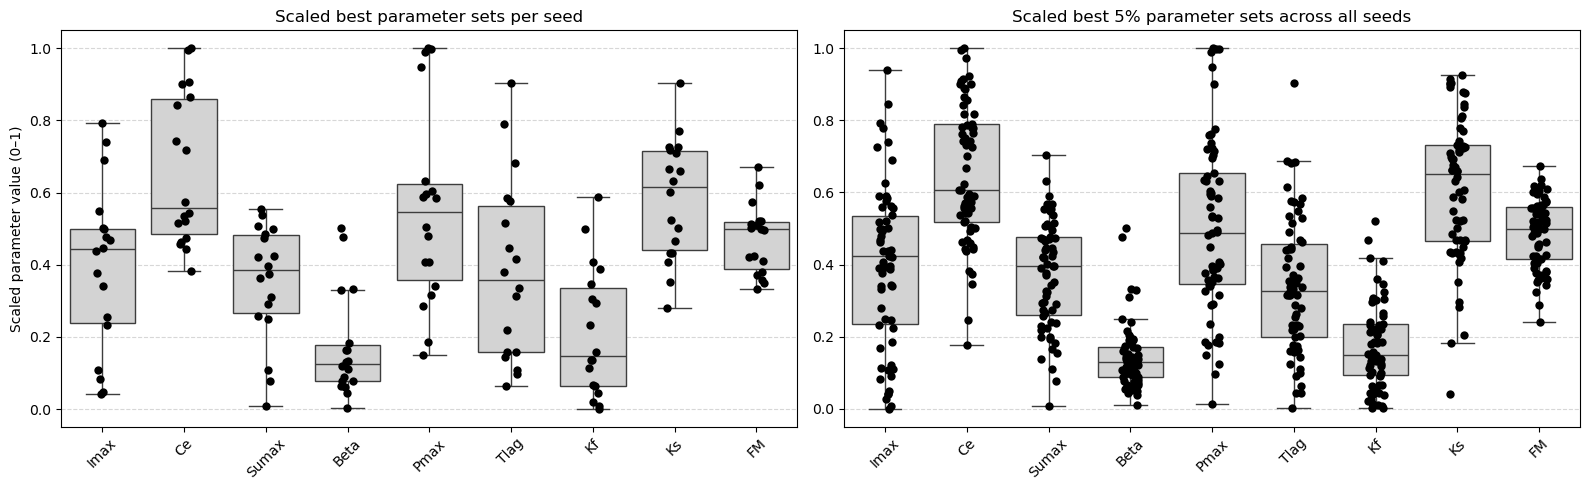

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()), columns=param_cols
)

scaled_best_5pct = pd.DataFrame(scale(best_5pct_df[param_cols].to_numpy()), columns=param_cols)

# Create figure with 2 subplots
plt.figure(figsize=(16, 5))

# Left: best per seed
plt.subplot(1, 2, 1)
sns.boxplot(data=scaled_best_per_seed, color="lightgray", fliersize=0)
sns.stripplot(data=scaled_best_per_seed, color="black", jitter=True, size=6, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0–1)")
plt.title("Scaled best parameter sets per seed")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Right: top 5%
plt.subplot(1, 2, 2)
sns.boxplot(data=scaled_best_5pct, color="lightgray", fliersize=0)
sns.stripplot(data=scaled_best_5pct, color="black", jitter=True, size=6, marker="o")
plt.xticks(rotation=45)
plt.ylabel("")
plt.title("Scaled best 5% parameter sets across all seeds")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Parameter columns
param_cols = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]

# Scale both datasets
scaled_best_per_seed = pd.DataFrame(
    scale(best_params_df[param_cols].to_numpy()), columns=param_cols
)
scaled_best_5pct = pd.DataFrame(scale(best_5pct_df[param_cols].to_numpy()), columns=param_cols)

# Add a column to identify the group
scaled_best_per_seed["group"] = "best per seed"
scaled_best_5pct["group"] = f"top {int(100*q)}%"

# Combine both datasets
combined_df = pd.concat([scaled_best_per_seed, scaled_best_5pct], ignore_index=True)

# Melt to long format for seaborn
long_df = combined_df.melt(
    id_vars="group", value_vars=param_cols, var_name="parameter", value_name="scaled_value"
)

In [18]:
long_df["group"].unique()

array(['best per seed', 'top 1%'], dtype=object)

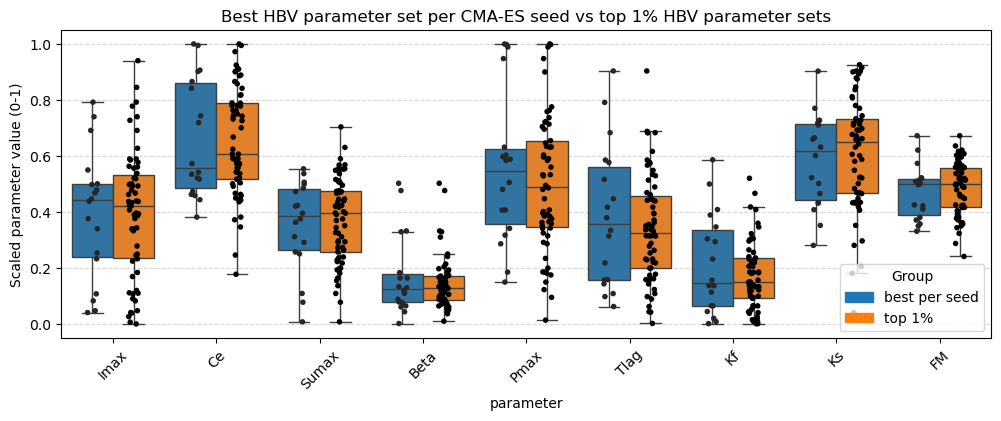

In [19]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

# palette = {
#     'best per seed': 'darkgray',
#     f"top {int(100*q)}%": 'dimgray'
# }

palette = {
    "best per seed": "#1f77b4",  # blue
    f"top {int(100*q)}%": "#ff7f0e",  # orange
}


sns.boxplot(
    data=long_df, x="parameter", y="scaled_value", hue="group", palette=palette, fliersize=0
)

sns.stripplot(
    data=long_df,
    x="parameter",
    y="scaled_value",
    hue="group",
    dodge=True,
    jitter=True,
    size=4,
    marker="o",
    alpha=1,
    palette="dark:black",
    legend=False,  # avoid duplicate legend entries
)

# 3️⃣ Custom legend from boxplot colors only
handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
plt.legend(handles=handles, title="Group")

plt.xticks(rotation=45)
plt.ylabel("Scaled parameter value (0-1)")
plt.title(f"Best HBV parameter set per CMA-ES seed vs top {int(100*q)}% HBV parameter sets")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [20]:
loaded_results

[{'seed': 101010,
  'best_f': 0.18279455472171757,
  'best_x': array([0.25424959, 0.71925128, 0.25098182, 0.16461212, 0.3176509 ,
         0.37973341, 0.38945857, 0.65966075, 0.33170221]),
  'nfev': 336,
  'sigma_final': 0.23639728063754964,
  'history': {'theta_norm': [array([0.46422322, 0.66606402, 0.52987486, 0.69488325, 0.3764541 ,
           0.5729906 , 0.52933857, 0.58763933, 0.45363599]),
    array([0.59897616, 0.63522176, 0.10117505, 0.38751941, 0.50377499,
           0.60122333, 0.53498612, 0.35300277, 0.72768941]),
    array([0.74004124, 0.45662706, 0.61976235, 0.49696911, 0.58794005,
           0.61529379, 0.43301501, 0.7296296 , 0.52906055]),
    array([0.45721715, 0.43096984, 0.48599786, 0.59758274, 0.41083642,
           0.54984876, 0.53160194, 0.48331134, 0.55183408]),
    array([0.43360457, 0.69265652, 0.54502208, 0.46895672, 0.51864903,
           0.77097261, 0.54847841, 0.47938721, 0.36122712]),
    array([0.47666797, 0.41653243, 0.56425383, 0.49869106, 0.32226013,
  

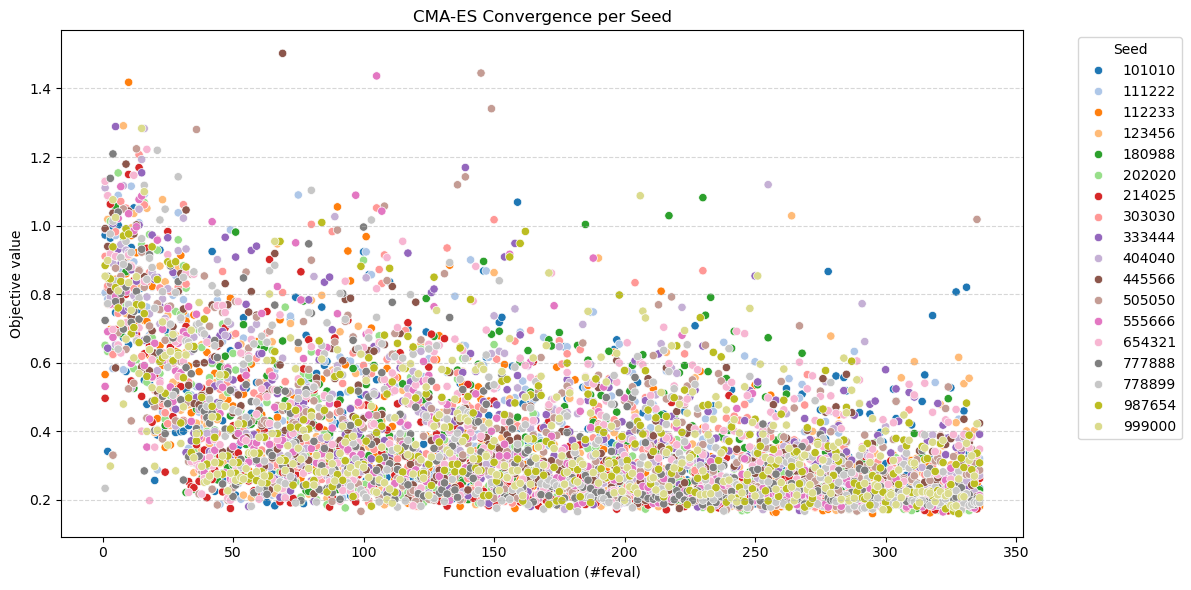

In [21]:
plot_data = []

for run in loaded_results:
    seed = run["seed"]
    history = run["history"]

    fevals = list(range(1, len(history["objective"]) + 1))  # #feval
    objectives = history["objective"]

    for f, obj in zip(fevals, objectives):
        plot_data.append({"seed": seed, "feval": f, "objective": obj})

df_plot = pd.DataFrame(plot_data)

# Plot
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_plot,
    x="feval",
    y="objective",
    hue="seed",
    marker="o",
    palette="tab20",  # can use any palette
)

plt.xlabel("Function evaluation (#feval)")
plt.ylabel("Objective value")
plt.title("CMA-ES Convergence per Seed")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Seed", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

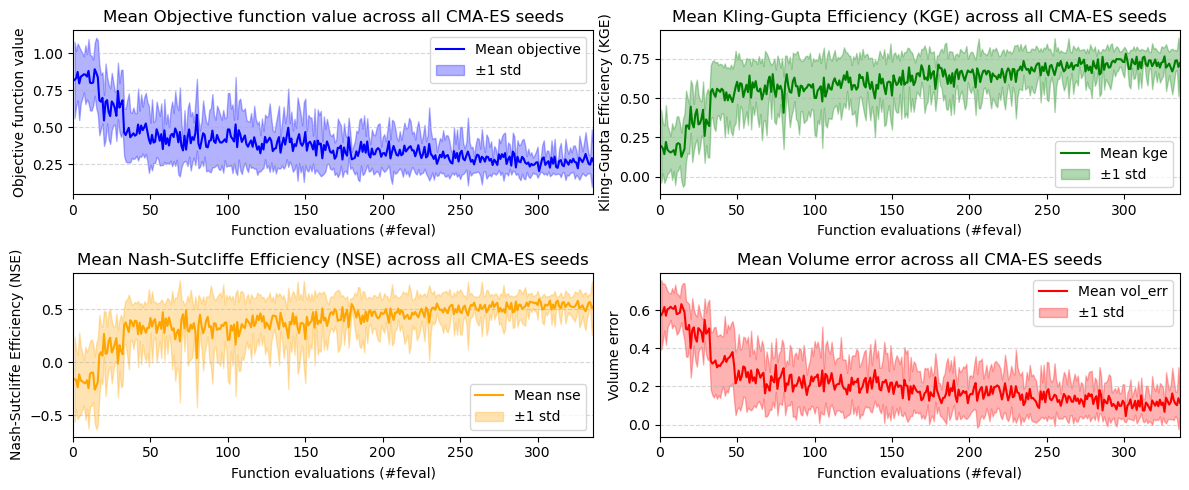

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

metrics = ["objective", "kge", "nse", "vol_err"]

# Mapping from metric key to long/descriptive name
metric_names = {
    "objective": "Objective function value",
    "kge": "Kling-Gupta Efficiency (KGE)",
    "nse": "Nash-Sutcliffe Efficiency (NSE)",
    "vol_err": "Volume error",
}

# Build DataFrame of all seeds and metrics
plot_data = []

for run in loaded_results:
    seed = run["seed"]
    history = run["history"]
    fevals = np.arange(1, len(history["objective"]) + 1)

    for f in fevals:
        row = {"seed": seed, "feval": f}
        for m in metrics:
            row[m] = history[m][f - 1]  # f-1 because fevals start at 1
        plot_data.append(row)

df_plot = pd.DataFrame(plot_data)

# Plot mean ± std for each metric
plt.figure(figsize=(12, 5))

colors = {"objective": "blue", "kge": "green", "nse": "orange", "vol_err": "red"}

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)

    df_summary = df_plot.groupby("feval")[metric].agg(["mean", "std"]).reset_index()

    plt.plot(df_summary["feval"], df_summary["mean"], color=colors[metric], label=f"Mean {metric}")
    plt.fill_between(
        df_summary["feval"],
        df_summary["mean"] - df_summary["std"],
        df_summary["mean"] + df_summary["std"],
        color=colors[metric],
        alpha=0.3,
        label="±1 std",
    )

    plt.xlabel("Function evaluations (#feval)")
    plt.ylabel(metric_names[metric])
    plt.title(f"Mean {metric_names[metric]} across all CMA-ES seeds")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.legend()
    plt.xlim(0, 336)

plt.tight_layout()
plt.show()